In [1]:
import numpy as np
import pandas as pd
import numpy as np
from ase import Atoms
import os
import json


In [2]:
folder = "/home/mauduit/EPFL/dataset"

rows = []

for f in os.listdir(folder):
    path = os.path.join(folder, f)
    with open(path, "r") as file:
        data = json.load(file)
        
        if isinstance(data, list):
            rows.extend(data)   # plusieurs lignes
        else:
            rows.append(data)   # une seule ligne

all_data = pd.DataFrame(rows)

all_data = all_data.drop([1243, 3408, 4417]) # the id 731 was doubled
all_data = all_data[all_data["config_type"] != "surface_111_3x3_das"] # only config with one occurence

In [4]:
# from ase.io import read, write

# folder = "/home/mauduit/EPFL/Modified_GAP_Julia"
# new_silicon = "silicon_subset"

# file = folder + "/silicon.xyz"

# configs = read(file, index=":")
# configs = [configs[0]] + configs[399:450]

# print("len =", len(configs))

# write(folder + "/" + new_silicon + ".xyz", configs)

# print(new_silicon + ".xyz done")

In [3]:
# dataset10 = all_data[(all_data["Ecut"] == 10) & (all_data["config_type"] == "fcc")]
dataset10 = all_data[(all_data["Ecut"] == 10)]
dataset18 = all_data[(all_data["Ecut"] == 18)]
dataset26 = all_data[(all_data["Ecut"] == 26)]
print(dataset10.shape)
print(dataset18.shape)
print(dataset26.shape)



(1725, 19)
(1725, 19)
(1725, 19)


In [4]:
def vol(dataset):
    dataset["volume"] = 0. 
    ids = dataset["structure_id"].unique()
    for id in ids :
        lattice = dataset.loc[dataset["structure_id"] == id, "lattice"].iloc[0]
        coords_lattice = np.array(lattice["fields"]["data"]).reshape(3, 3)
        dataset.loc[dataset["structure_id"] == id, "volume"] = np.abs(np.linalg.det(coords_lattice))

vol(dataset10)
vol(dataset18)
vol(dataset26)


In [5]:
def xyz_build(dataset, name, L = None):
    frames = []

    if L is None :
        ids = dataset["structure_id"].unique()
        i = 0
        for id in ids :
                    
            structure = dataset.loc[dataset["structure_id"] == id, "atomic_symbols"].iloc[0]

            pos = dataset.loc[dataset["structure_id"] == id, "atomic_positions_cart"].iloc[0]
            coords = np.array([atom["fields"]["data"] for atom in pos]) 


            lattice = dataset.loc[dataset["structure_id"] == id, "lattice"].iloc[0]
            coords_lattice = np.array(lattice["fields"]["data"]).reshape(3, 3) 

            stresses = dataset.loc[dataset["structure_id"] == id, "stress"].iloc[0]
            coords_stress = np.array(stresses["fields"]["data"]) 

            energy = dataset.loc[dataset["structure_id"] == id, "energies/total"].iloc[0]
            volume = dataset.loc[dataset["structure_id"] == id, "volume"].iloc[0] 

            force = np.array(dataset.loc[dataset["structure_id"] == id, "forces"].iloc[0])
            forces = np.array([atom["fields"]["data"] for atom in force]) 

            forces_reduced = np.array([atom["fields"]["data"] for atom in force])

            forces_cart = forces_reduced @ np.linalg.inv(coords_lattice)

            atoms = Atoms(structure,
                            positions = coords,
                            cell = coords_lattice,
                            pbc = True
                            )
    
            atoms.info["dft_energy"] = energy
            atoms.info["volume"] = volume
            atoms.arrays["dft_force"] = forces_cart
            atoms.info["dft_virial"] = coords_stress
            atoms.info["id"] = id
            frames.append(atoms)
        
    else :
        assert isinstance(dataset, pd.Series)
        structure = dataset["atomic_symbols"]
        pos = dataset["atomic_positions_cart"]
        lattice = dataset["lattice"]
        energy = dataset["energies/total"]

        base_positions = np.array([atom["fields"]["data"] for atom in pos])
        base_lattice = np.array(lattice["fields"]["data"]).reshape(3, 3)

        for l in L :
            coords = base_positions * l
            coords_lattice = base_lattice * l
            atoms = Atoms(
                structure,
                positions=coords,
                cell=coords_lattice,
                pbc=True
            )
            
            frames.append(atoms)
    # write trajectory
    from ase.io import write
    write(f"{name}.xyz", frames)
    print(f"{name}.xyz", "done")


In [6]:
bcc = dataset26[dataset26["config_type"] == "bcc"]
fcc = dataset26[dataset26["config_type"] == "fcc"]
hcp = dataset26[dataset26["config_type"] == "hcp"]
dia = dataset26[dataset26["config_type"] == "dia"]
dia = dia[dia["n_atoms"] < 16]

len(bcc), len(fcc), len(hcp), len(dia)

(49, 49, 49, 104)

In [7]:
xyz_build(bcc, "bcc")
# xyz_build(fcc, "fcc")
# xyz_build(hcp, "hcp")
# xyz_build(dia, "dia")

bcc.xyz done


In [6]:
train10 = dataset10[dataset10["config_type"].isin(["dia", "fcc", "hcp"])]
train18 = dataset18[dataset18["config_type"].isin(["dia", "fcc", "hcp"])]
train26 = dataset26[dataset26["config_type"].isin(["dia", "fcc", "hcp"])]
train10 = train10[train10["n_atoms"] < 16]
train18 = train18[train18["n_atoms"] < 16]
train26 = train26[train26["n_atoms"] < 16]

In [9]:
xyz_build(train10, "train10nobccCart")
xyz_build(train18, "train18nobccCart")
xyz_build(train26, "train26nobccCart")

train10nobccCart.xyz done
train18nobccCart.xyz done
train26nobccCart.xyz done


In [ ]:
#TODO add stresses

def xyz_build_log_difference(dataset, name, L = None):
    frames = []

    if L is None :
        ids = dataset["structure_id"].unique()

        for id in ids :
                    
            structure = dataset.loc[dataset["structure_id"] == id, "atomic_symbols"].iloc[0]

            pos = dataset.loc[dataset["structure_id"] == id, "atomic_positions_cart"].iloc[0]
            coords = [atom["fields"]["data"] for atom in pos]


            lattice = dataset.loc[dataset["structure_id"] == id, "lattice"].iloc[0]
            coords_lattice = np.array(lattice["fields"]["data"]).reshape(3, 3)

            energy10 = dataset10.loc[dataset10["structure_id"] == id, "energies/total"].iloc[0]
            energy = dataset.loc[dataset["structure_id"] == id, "energies/total"].iloc[0]

            stresses = dataset.loc[dataset["structure_id"] == id, "stress"].iloc[0]
            stresses10 = dataset10.loc[dataset10["structure_id"] == id, "stress"].iloc[0]

            coords_stress = np.array(stresses["fields"]["data"])
            coords_stress10 = np.array(stresses10["fields"]["data"])

            volume = dataset.loc[dataset["structure_id"] == id, "volume"].iloc[0]

            force = np.array(dataset.loc[dataset["structure_id"] == id, "forces"].iloc[0])
            forces = np.array([atom["fields"]["data"] for atom in force])

            force10 = np.array(dataset10.loc[dataset10["structure_id"] == id, "forces"].iloc[0])
            forces10 = np.array([atom["fields"]["data"] for atom in force10])

            atoms = Atoms(structure,
                            positions = coords,
                            cell = coords_lattice,
                            pbc = True
                            )
            atoms.info["dft_energy"] = energy10 - energy
            atoms.info["volume"] = volume
            atoms.arrays["dft_force"] = forces10 - forces 
            atoms.info["dft_virial"] = coords_stress10 - coords_stress
            atoms.info["id"] = id
            frames.append(atoms)

    # write trajectory
    from ase.io import write
    write(f"{name}_diff.xyz", frames)
    print(f"{name}_diff.xyz", "done")

: 

In [ ]:
xyz_build_log_difference(fcc18, "fcc18")
xyz_build_log_difference(fcc26, "fcc26")

fcc18_diff.xyz done
fcc26_diff.xyz done


: 

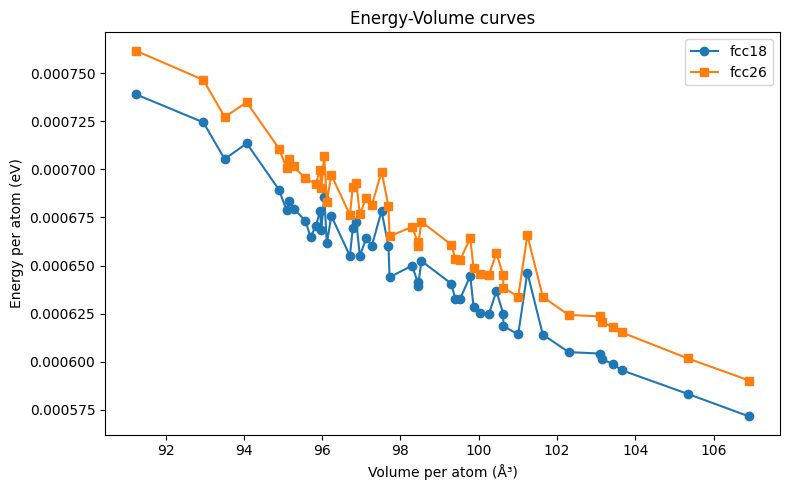

: 

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from ase.io import read

path = "/home/mauduit/EPFL/Modified_GAP_Julia/"
file18 = path + "fcc18_diff.xyz"
file26 = path + "fcc26_diff.xyz"

configs18 = read(file18, index=":")
configs26 = read(file26, index=":")

def extract_EV_per_atom(configs):
    E = []
    V = []
    for atoms in configs:
        nat = len(atoms)
        # Cherche la clé énergie dans atoms.info
        energy = atoms.info.get('dft_energy')

        E.append(energy / nat)
        V.append(atoms.info.get("volume") / nat)
    return np.array(V), np.array(E)

V18, E18 = extract_EV_per_atom(configs18)
V26, E26 = extract_EV_per_atom(configs26)

# Tri par volume croissant
idx18 = np.argsort(V18)
idx26 = np.argsort(V26)

plt.figure(figsize=(8, 5))
plt.plot(V18[idx18], E18[idx18], 'o-', label='fcc18')
plt.plot(V26[idx26], E26[idx26], 's-', label='fcc26')
plt.xlabel("Volume per atom (Å³)")
plt.ylabel("Energy per atom (eV)")
plt.title("Energy-Volume curves")
plt.legend()
plt.tight_layout()
plt.show()